In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [6]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

In [7]:
orders_clean[['order_delivered_customer_date', 'order_estimated_delivery_date']].isnull().sum()

order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64

In [8]:
orders_clean['real_delivery_day'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']).dt.days

In [9]:
orders_clean['estimated_delivery_day'] = (orders_clean['order_estimated_delivery_date'] - orders_clean['order_purchase_timestamp']).dt.days

In [10]:
orders_clean['difference_days'] = (orders_clean['estimated_delivery_day'] - orders_clean['real_delivery_day'])

In [11]:
orders_clean[['real_delivery_day', 'estimated_delivery_day', 'difference_days']].head(3)

,real_delivery_day,estimated_delivery_day,difference_days
0,8.0,15,7.0
1,13.0,19,6.0
2,9.0,26,17.0


In [12]:
orders_geo = pd.merge(orders_clean, customers[['customer_id', 'customer_state']], on='customer_id', how='inner')

In [13]:
orders_geo.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,real_delivery_day,estimated_delivery_day,difference_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,7.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,6.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,17.0,GO


In [14]:
orders_geo['real_delivery_day'].mean()

np.float64(12.093604229294082)

In [15]:
orders_geo['difference_days'].mean()

np.float64(11.279143775266922)

In [16]:
orders_geo[['real_delivery_day', 'estimated_delivery_day', 'difference_days']].describe()

,real_delivery_day,estimated_delivery_day,difference_days
count,96470.000000,96478.000000,96470.000000
mean,12.093604,23.372759,11.279144
std,9.551380,8.758137,10.192137
min,0.000000,2.000000,-189.000000
25%,6.000000,18.000000,7.000000
50%,10.000000,23.000000,12.000000
75%,15.000000,28.000000,16.000000
max,209.000000,155.000000,146.000000


In [17]:
orders_geo.groupby('customer_state')['real_delivery_day'].mean().sort_values(ascending=False).head(5)

customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
Name: real_delivery_day, dtype: float64

In [18]:
orders_geo.groupby('customer_state')['real_delivery_day'].mean().sort_values(ascending=True).head(5)


customer_state
SP     8.298094
PR    11.526711
MG    11.542188
DF    12.509135
SC    14.475183
Name: real_delivery_day, dtype: float64

In [19]:
promedio_por_estado = orders_geo.groupby('customer_state')['real_delivery_day'].mean().round(1).sort_values()


In [20]:
promedio_por_estado.head(5)

customer_state
SP     8.3
MG    11.5
PR    11.5
DF    12.5
SC    14.5
Name: real_delivery_day, dtype: float64

In [21]:
df_reviews = order_items.merge(products, on = 'product_id').merge(reviews, on = 'order_id').merge(translation, on='product_category_name', how='left')

In [22]:
df_reviews['product_category_name_english'].isnull().sum()

np.int64(1622)

In [23]:
len(df_reviews)

112372

In [24]:
df_reviews[df_reviews['product_category_name_english'].isnull()]['product_category_name'].unique()

<StringArray>
[nan, 'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer']
Length: 3, dtype: str

In [25]:
df_reviews[df_reviews['product_category_name_english'].isnull()]['product_category_name'].value_counts(dropna=False)

product_category_name
NaN                                              1598
portateis_cozinha_e_preparadores_de_alimentos      15
pc_gamer                                            9
Name: count, dtype: int64

In [26]:
df_reviews['product_category_name_english'] = df_reviews['product_category_name_english'].fillna(df_reviews['product_category_name'])

In [27]:
cate_summary = df_reviews.groupby('product_category_name_english')['review_score'].agg(['mean', 'count'])

In [28]:
cate_insatisfaccion = cate_summary[cate_summary['count'] > 50].sort_values(by='mean', ascending=True).head(10)


In [29]:
cate_insatisfaccion.head(10)

,mean,count
product_category_name_english,,
office_furniture,3.493183,1687
fashion_male_clothing,3.641221,131
fixed_telephony,3.683206,262
audio,3.825485,361
home_confort,3.829885,435
construction_tools_safety,3.844560,193
bed_bath_table,3.895663,11137
furniture_decor,3.903493,8331
furniture_living_room,3.904382,502


In [30]:
cate_insatisfaccion['mean'] = cate_insatisfaccion['mean'].round(2)

In [31]:
cate_insatisfaccion

,mean,count
product_category_name_english,,
office_furniture,3.49,1687
fashion_male_clothing,3.64,131
fixed_telephony,3.68,262
audio,3.83,361
home_confort,3.83,435
construction_tools_safety,3.84,193
bed_bath_table,3.90,11137
furniture_decor,3.90,8331
furniture_living_room,3.90,502


In [32]:
import os

In [33]:
os.makedirs('marts', exist_ok=True)

In [34]:
fact_orders = orders_clean[[
    'order_id', 'customer_id', 'order_status',
    'real_delivery_day', 'estimated_delivery_day', 'difference_days'
]].copy()

In [35]:
fact_orders. head(5)

,order_id,customer_id,order_status,real_delivery_day,estimated_delivery_day,difference_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8.0,15,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,13.0,19,6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,9.0,26,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,13.0,26,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2.0,12,10.0


In [36]:
dim_customers = customers[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']].copy()

In [37]:
dim_customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [38]:
fact_orders.to_csv('marts/fact_orders.csv', index=False)

In [39]:
dim_customers.to_csv('marts/dim_customers.csv', index=False)

In [40]:
print("--- FACT ORDERS ---")
display(fact_orders.head(3))

--- FACT ORDERS ---


,order_id,customer_id,order_status,real_delivery_day,estimated_delivery_day,difference_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,8.0,15,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,13.0,19,6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,9.0,26,17.0


In [41]:
print("--- DIM CUSTOMERS ---")
display(dim_customers.head(3))

--- DIM CUSTOMERS ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [42]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [43]:
import matplotlib.pyplot as plt

In [44]:
BG = '#F7F3EC'
TEXT = '#22314A'
ACCENT = '#E4572E'
NEUTRAL = '#C9C4BA'
LINE_EST = '#8AA1C4'

In [45]:
plt.rcParams['text.color'] = TEXT

In [46]:
plt.rcParams['axes.labelcolor'] = TEXT
plt.rcParams['xtick.color'] = TEXT
plt.rcParams['ytick.color'] = TEXT

In [47]:
plt.rcParams['axes.edgecolor'] = NEUTRAL

In [48]:
orders_geo['year_month'] = orders_geo['order_purchase_timestamp'].dt.to_period('M')

In [49]:
evolucion_mensual = (orders_geo
                      .groupby('year_month')[['real_delivery_day', 'estimated_delivery_day']]
                      .mean())

In [50]:
evolucion_mensual.index = evolucion_mensual.index.to_timestamp()

In [51]:
evolucion_mensual.head()
evolucion_mensual.tail()

,real_delivery_day,estimated_delivery_day
year_month,,
2018-04-01,11.048544,23.314504
2018-05-01,10.959105,22.527486
2018-06-01,8.774442,27.405476
2018-07-01,8.503736,19.332522
2018-08-01,7.286412,14.820343


In [52]:
evolucion_mensual.isnull().sum()

real_delivery_day         0
estimated_delivery_day    0
dtype: int64

In [53]:
display(evolucion_mensual.head())
display(evolucion_mensual.tail())

,real_delivery_day,estimated_delivery_day
year_month,,
2016-09-01,54.000000,18.000000
2016-10-01,19.135849,55.309434
2016-12-01,4.000000,26.000000
2017-01-01,12.092000,39.161333
2017-02-01,12.606171,31.495463


,real_delivery_day,estimated_delivery_day
year_month,,
2018-04-01,11.048544,23.314504
2018-05-01,10.959105,22.527486
2018-06-01,8.774442,27.405476
2018-07-01,8.503736,19.332522
2018-08-01,7.286412,14.820343


In [54]:
conteo_mensual = orders_geo.groupby('year_month').size()
conteo_mensual.tail()

year_month
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, dtype: int64

In [55]:
conteo_mensual.head(10)

year_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
Freq: M, dtype: int64

In [56]:
orders['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

In [57]:
evolucion_filtrada = evolucion_mensual.loc['2017-01':'2018-07']

In [58]:
evolucion_filtrada

,real_delivery_day,estimated_delivery_day
year_month,,
2017-01-01,12.092000,39.161333
2017-02-01,12.606171,31.495463
2017-03-01,12.395522,24.371563
2017-04-01,14.352584,26.994789
2017-05-01,10.760508,23.926114
2017-06-01,11.506220,23.657097
2017-07-01,11.131198,22.959711
2017-08-01,10.700692,23.114000
2017-09-01,11.400723,22.070843


In [59]:
promedio_por_estado = orders_geo.groupby('customer_state')['real_delivery_day'].mean().sort_values()

colores_estado = [ACCENT if estado in ['SP', 'RR'] else NEUTRAL for estado in promedio_por_estado.index]

In [60]:
colores_estado

['#E4572E',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#C9C4BA',
 '#E4572E']

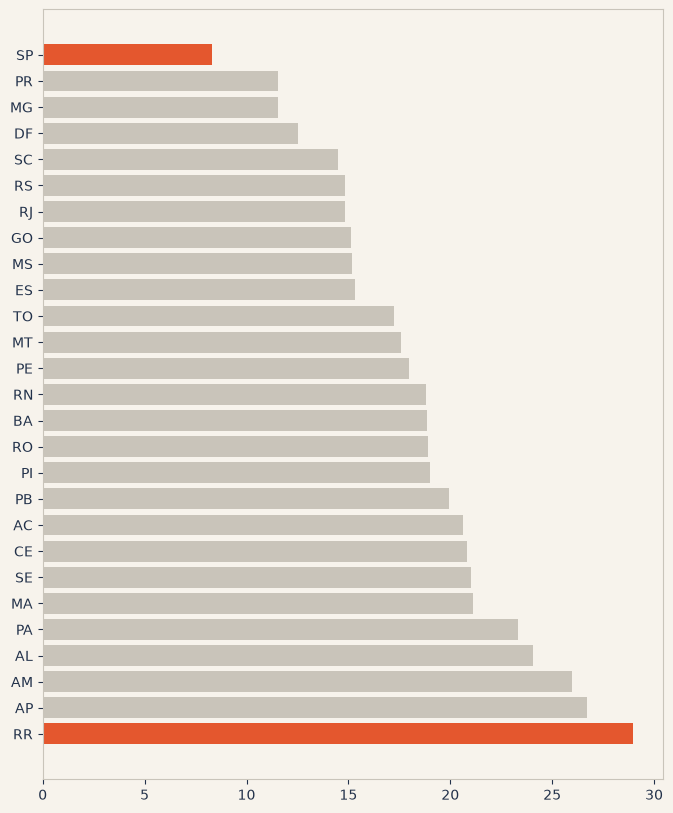

In [61]:
fig1, ax1 = plt.subplots(figsize=(8, 10))
ax1.barh(promedio_por_estado.index, promedio_por_estado.values, color=colores_estado)
ax1.invert_yaxis()
ax1.set_facecolor(BG)
fig1.patch.set_facecolor(BG)

In [62]:
ax1.set_title('Tiempo de entrega promedio por estado', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Días')

for spine in ['top', 'right', 'left']:
    ax1.spines[spine].set_visible(False)

for i, (estado, valor) in enumerate(promedio_por_estado.items()):
    if estado in ['SP', 'RR']:
        ax1.text(valor + 0.3, i, f'{valor:.1f}', va='center', color=ACCENT, fontweight='bold')

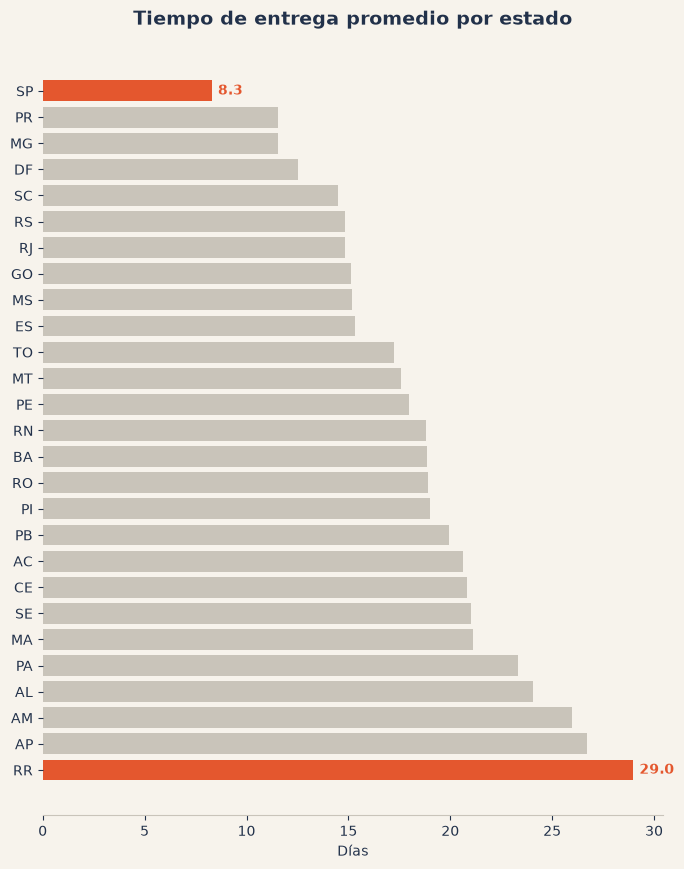

In [63]:
fig1

In [64]:
cate_summary_ordenado = cate_summary.sort_values('mean')
cate_summary_ordenado.head(15)

,mean,count
product_category_name_english,,
security_and_services,2.500000,2
diapers_and_hygiene,3.256410,39
portateis_cozinha_e_preparadores_de_alimentos,3.266667,15
pc_gamer,3.333333,9
office_furniture,3.493183,1687
home_comfort_2,3.629630,27
fashion_male_clothing,3.641221,131
fixed_telephony,3.683206,262
party_supplies,3.767442,43


In [65]:
cate_filtrada = cate_summary[cate_summary['count'] >= 100]
top_insatisfaccion = cate_filtrada.sort_values('mean').head(10)
top_insatisfaccion

,mean,count
product_category_name_english,,
office_furniture,3.493183,1687
fashion_male_clothing,3.641221,131
fixed_telephony,3.683206,262
audio,3.825485,361
home_confort,3.829885,435
construction_tools_safety,3.844560,193
bed_bath_table,3.895663,11137
furniture_decor,3.903493,8331
furniture_living_room,3.904382,502


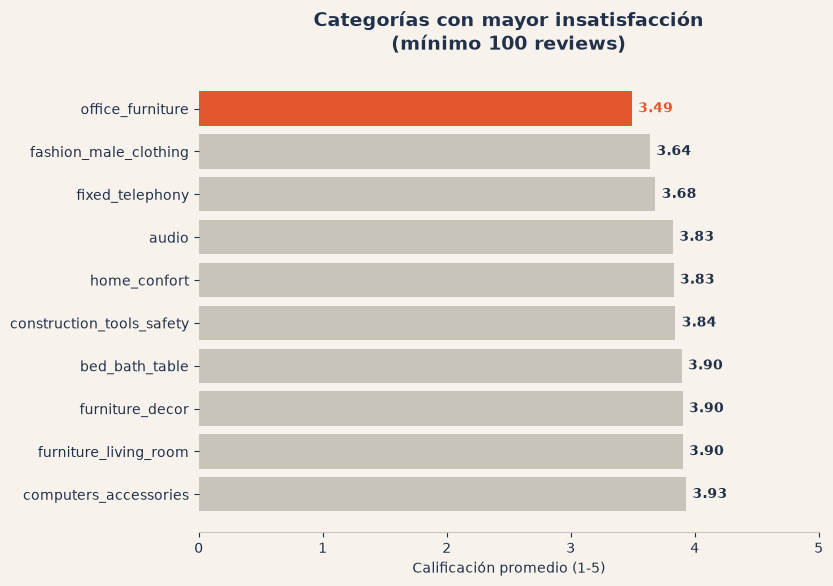

In [67]:
top_insatisfaccion_ordenado = top_insatisfaccion.sort_values('mean', ascending=False)

colores_categoria = [ACCENT if cat == 'office_furniture' else NEUTRAL for cat in top_insatisfaccion_ordenado.index]

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.barh(top_insatisfaccion_ordenado.index, top_insatisfaccion_ordenado['mean'], color=colores_categoria)

ax2.set_title('Categorías con mayor insatisfacción\n(mínimo 100 reviews)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Calificación promedio (1-5)')
ax2.set_xlim(0, 5)
ax2.set_facecolor(BG)
fig2.patch.set_facecolor(BG)

for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)

for i, valor in enumerate(top_insatisfaccion_ordenado['mean']):
    color_texto = ACCENT if top_insatisfaccion_ordenado.index[i] == 'office_furniture' else TEXT
    ax2.text(valor + 0.05, i, f'{valor:.2f}', va='center', color=color_texto, fontweight='bold')


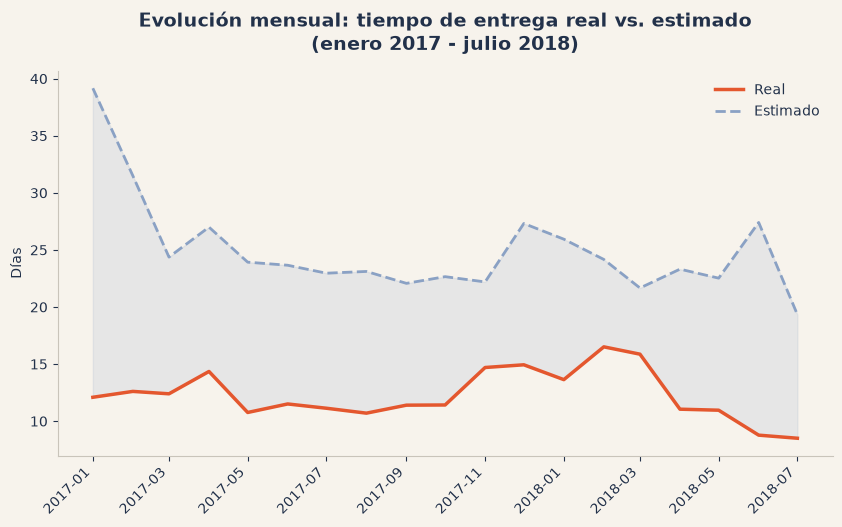

In [69]:
fig3, ax3 = plt.subplots(figsize=(10, 5))

ax3.plot(evolucion_filtrada.index, evolucion_filtrada['real_delivery_day'],
         color=ACCENT, linewidth=2.5, label='Real')
ax3.plot(evolucion_filtrada.index, evolucion_filtrada['estimated_delivery_day'],
         color=LINE_EST, linewidth=2, linestyle='--', label='Estimado')

ax3.fill_between(evolucion_filtrada.index,
                  evolucion_filtrada['real_delivery_day'],
                  evolucion_filtrada['estimated_delivery_day'],
                  color=LINE_EST, alpha=0.15)

ax3.set_title('Evolución mensual: tiempo de entrega real vs. estimado\n(enero 2017 - julio 2018)',
              fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Días')
ax3.set_facecolor(BG)
fig3.patch.set_facecolor(BG)

for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)

ax3.legend(frameon=False, loc='upper right')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right');
plt.show()

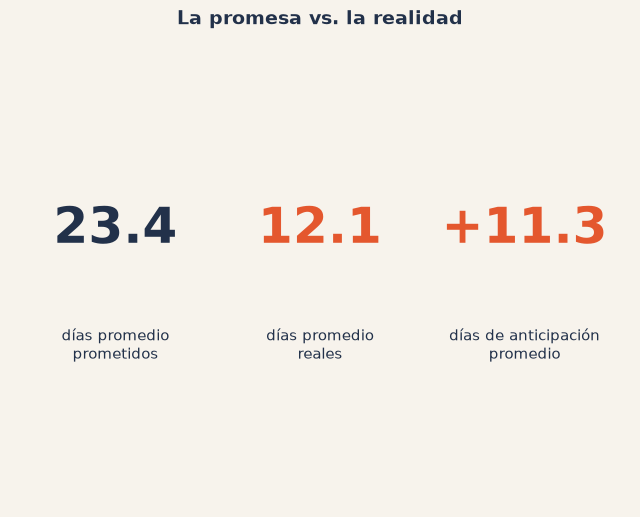

In [70]:
fig4, ax4 = plt.subplots(figsize=(8, 6))

ax4.set_facecolor(BG)
fig4.patch.set_facecolor(BG)
ax4.axis('off')

kpis = [
    ('23.4', 'días promedio\nprometidos', TEXT),
    ('12.1', 'días promedio\nreales', ACCENT),
    ('+11.3', 'días de anticipación\npromedio', ACCENT),
]

posiciones_x = [0.17, 0.5, 0.83]

for x, (numero, etiqueta, color) in zip(posiciones_x, kpis):
    ax4.text(x, 0.6, numero, transform=ax4.transAxes,
              fontsize=36, fontweight='bold', color=color,
              ha='center', va='center')
    ax4.text(x, 0.35, etiqueta, transform=ax4.transAxes,
              fontsize=11, color=TEXT,
              ha='center', va='center')

ax4.set_title('La promesa vs. la realidad', fontsize=14, fontweight='bold', pad=15)
plt.show()

Text(0.5, 0.98, 'Análisis logístico y de satisfacción del cliente — E-commerce')

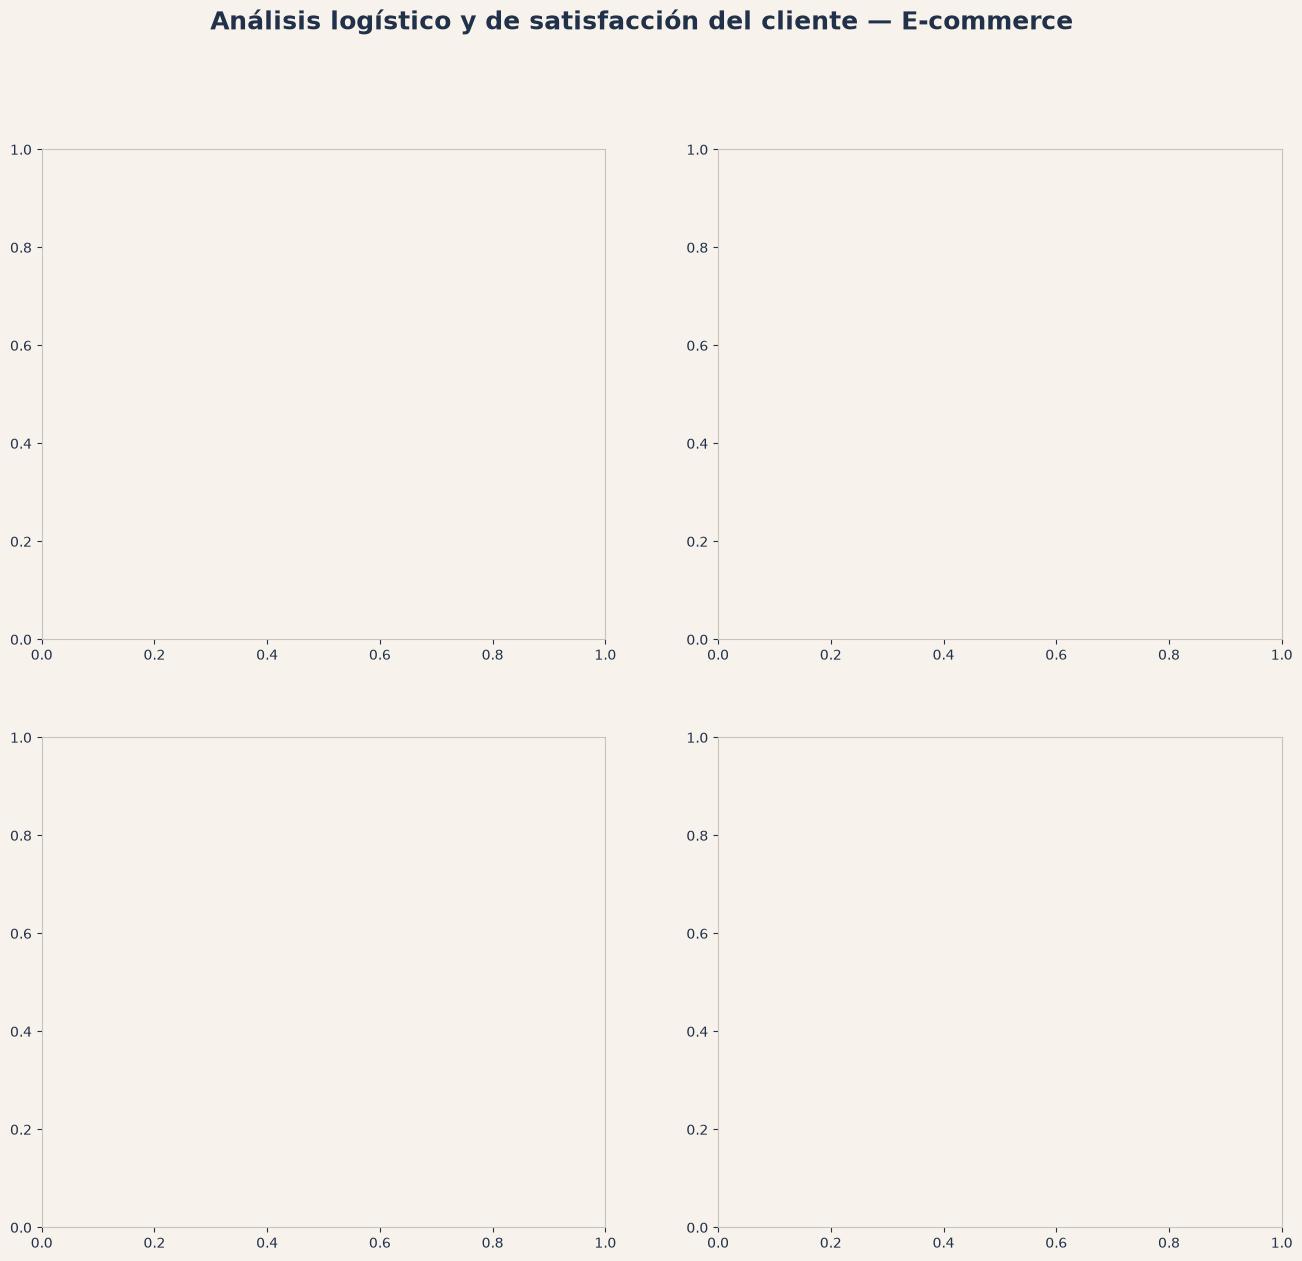

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.patch.set_facecolor(BG)

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor(BG)

fig.suptitle('Análisis logístico y de satisfacción del cliente — E-commerce',
             fontsize=18, fontweight='bold', y=0.98)

In [72]:
promedio_por_estado = orders_geo.groupby('customer_state')['real_delivery_day'].mean().sort_values()
colores_estado = [ACCENT if estado in ['SP', 'RR'] else NEUTRAL for estado in promedio_por_estado.index]

ax1.barh(promedio_por_estado.index, promedio_por_estado.values, color=colores_estado)
ax1.invert_yaxis()
ax1.set_title('Tiempo de entrega promedio por estado', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Días')

for spine in ['top', 'right', 'left']:
    ax1.spines[spine].set_visible(False)

for i, (estado, valor) in enumerate(promedio_por_estado.items()):
    if estado in ['SP', 'RR']:
        ax1.text(valor + 0.3, i, f'{valor:.1f}', va='center', color=ACCENT, fontweight='bold')

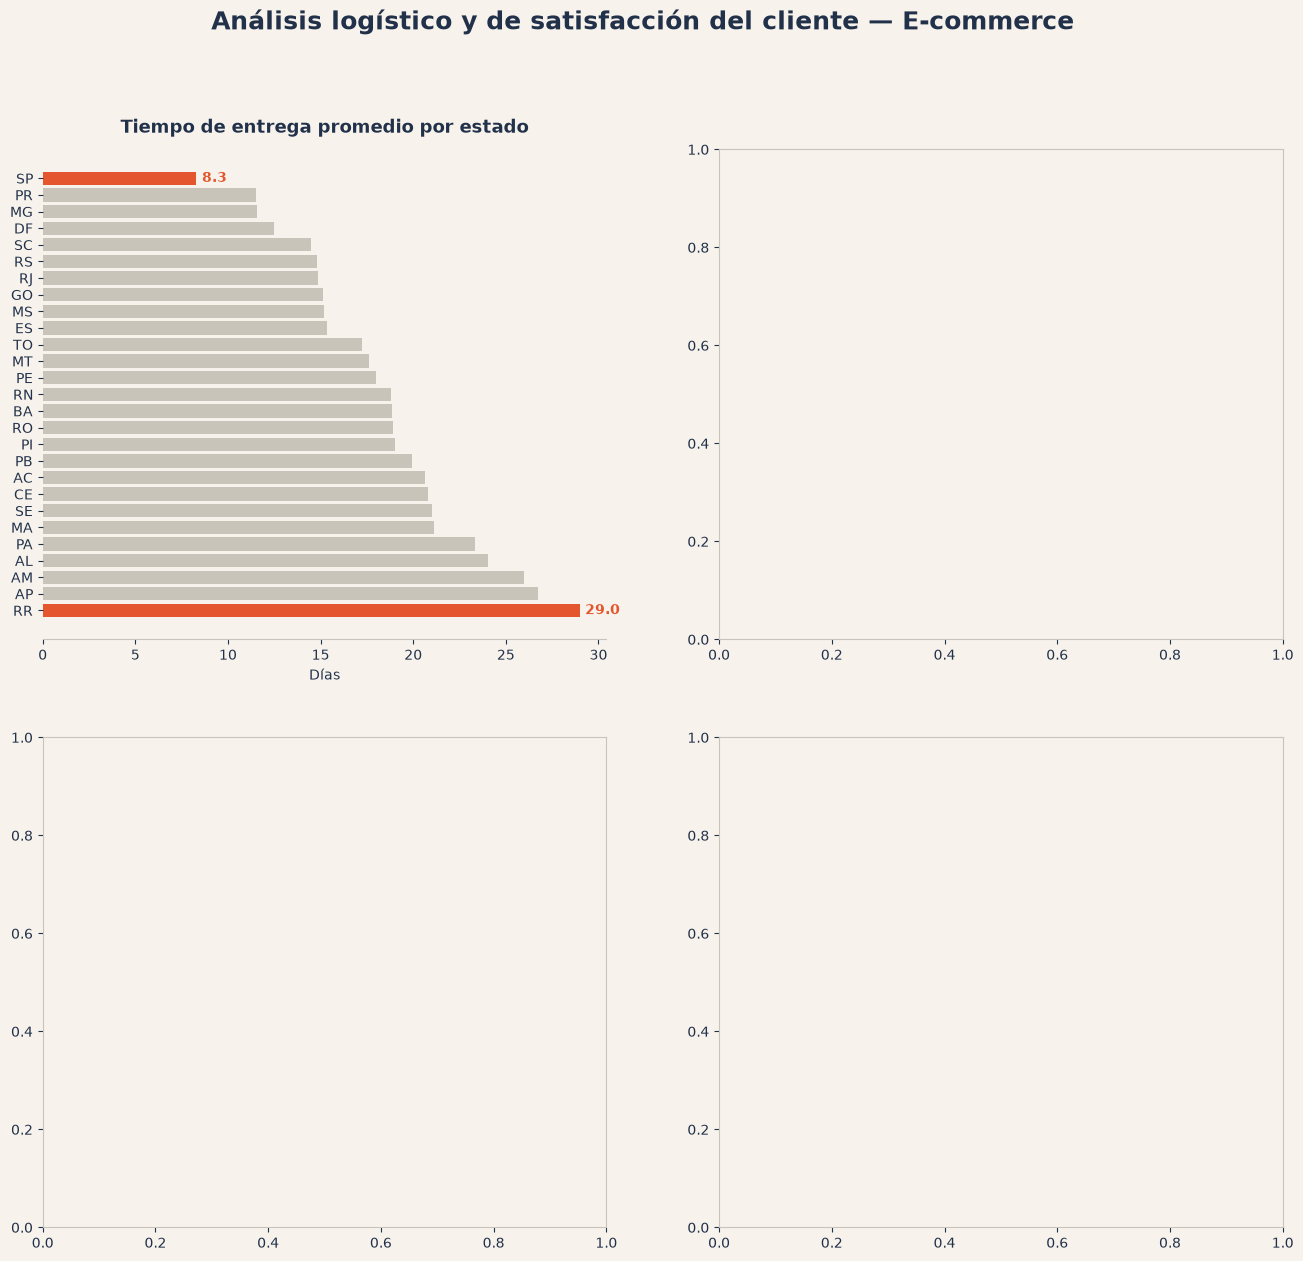

In [73]:
fig

In [74]:
top_insatisfaccion_ordenado = top_insatisfaccion.sort_values('mean', ascending=False)
colores_categoria = [ACCENT if cat == 'office_furniture' else NEUTRAL for cat in top_insatisfaccion_ordenado.index]

ax2.barh(top_insatisfaccion_ordenado.index, top_insatisfaccion_ordenado['mean'], color=colores_categoria)
ax2.set_title('Categorías con mayor insatisfacción\n(mínimo 100 reviews)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Calificación promedio (1-5)')
ax2.set_xlim(0, 5)

for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)

for i, valor in enumerate(top_insatisfaccion_ordenado['mean']):
    color_texto = ACCENT if top_insatisfaccion_ordenado.index[i] == 'office_furniture' else TEXT
    ax2.text(valor + 0.05, i, f'{valor:.2f}', va='center', color=color_texto, fontweight='bold')

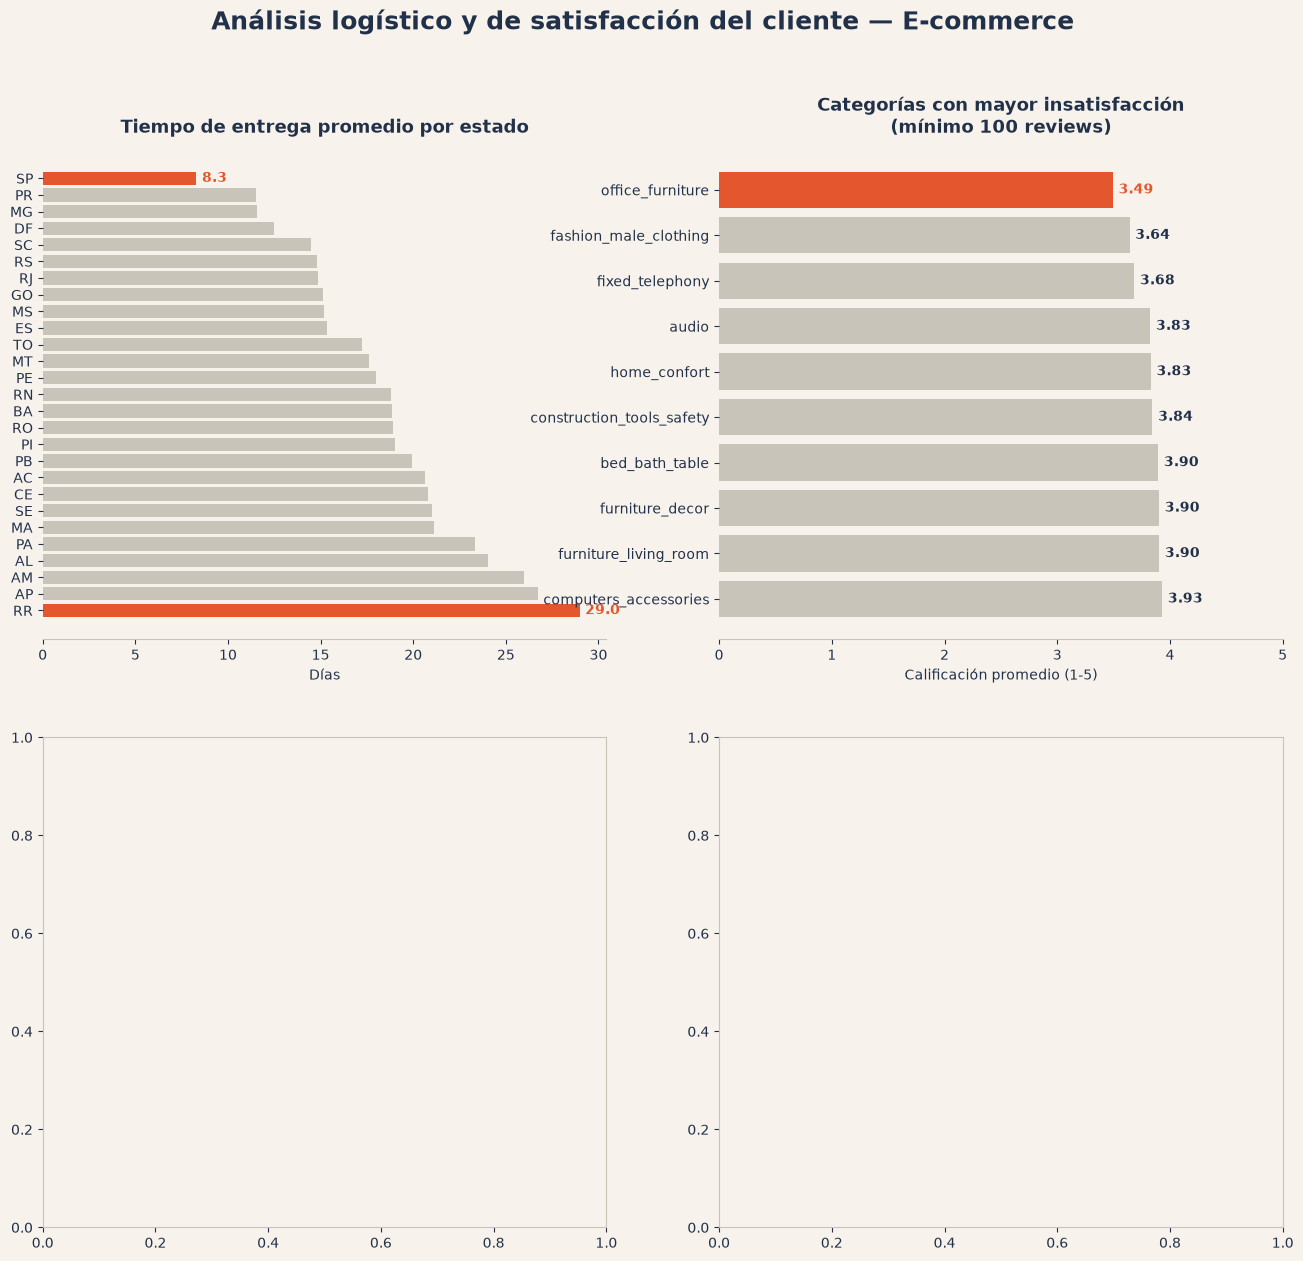

In [75]:
fig

In [76]:
fig.subplots_adjust(wspace=0.3, hspace=0.4)

In [77]:
ax1.set_xlim(0, promedio_por_estado.max() * 1.15)

(0.0, 33.321951219512194)

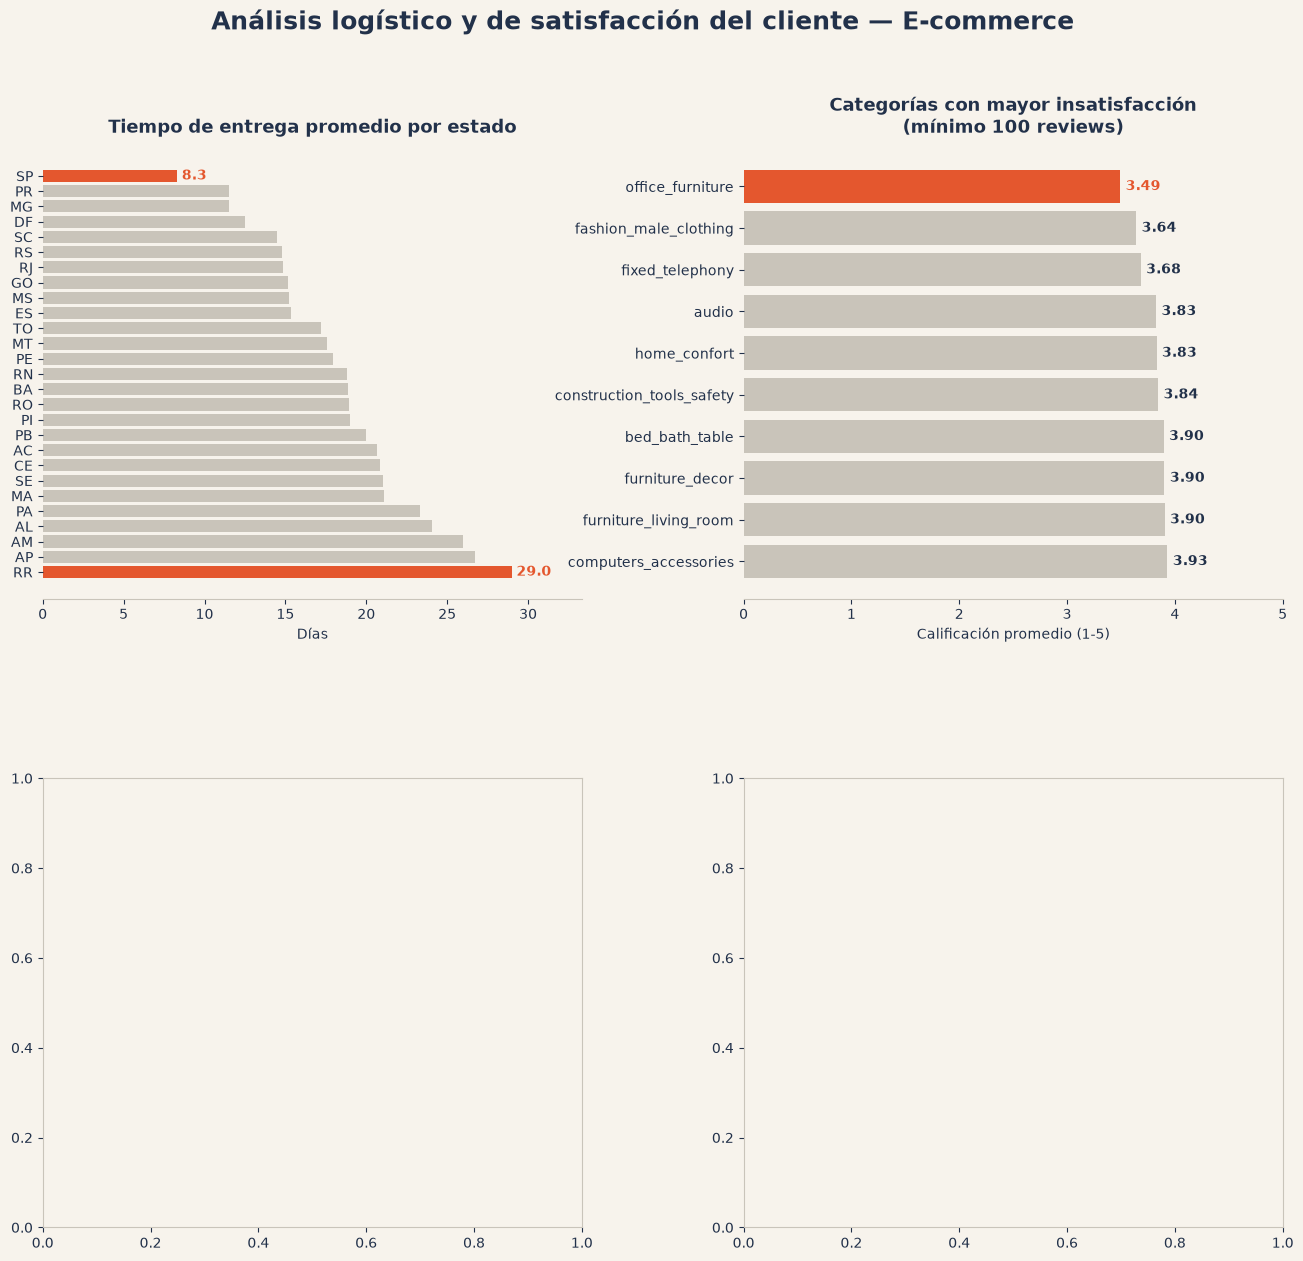

In [78]:
fig

In [79]:
ax3.plot(evolucion_filtrada.index, evolucion_filtrada['real_delivery_day'],
         color=ACCENT, linewidth=2.5, label='Real')
ax3.plot(evolucion_filtrada.index, evolucion_filtrada['estimated_delivery_day'],
         color=LINE_EST, linewidth=2, linestyle='--', label='Estimado')

ax3.fill_between(evolucion_filtrada.index,
                  evolucion_filtrada['real_delivery_day'],
                  evolucion_filtrada['estimated_delivery_day'],
                  color=LINE_EST, alpha=0.15)

ax3.set_title('Evolución mensual: real vs. estimado', fontsize=13, fontweight='bold', pad=12)
ax3.set_ylabel('Días')

for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)

ax3.legend(frameon=False, loc='upper right')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right');

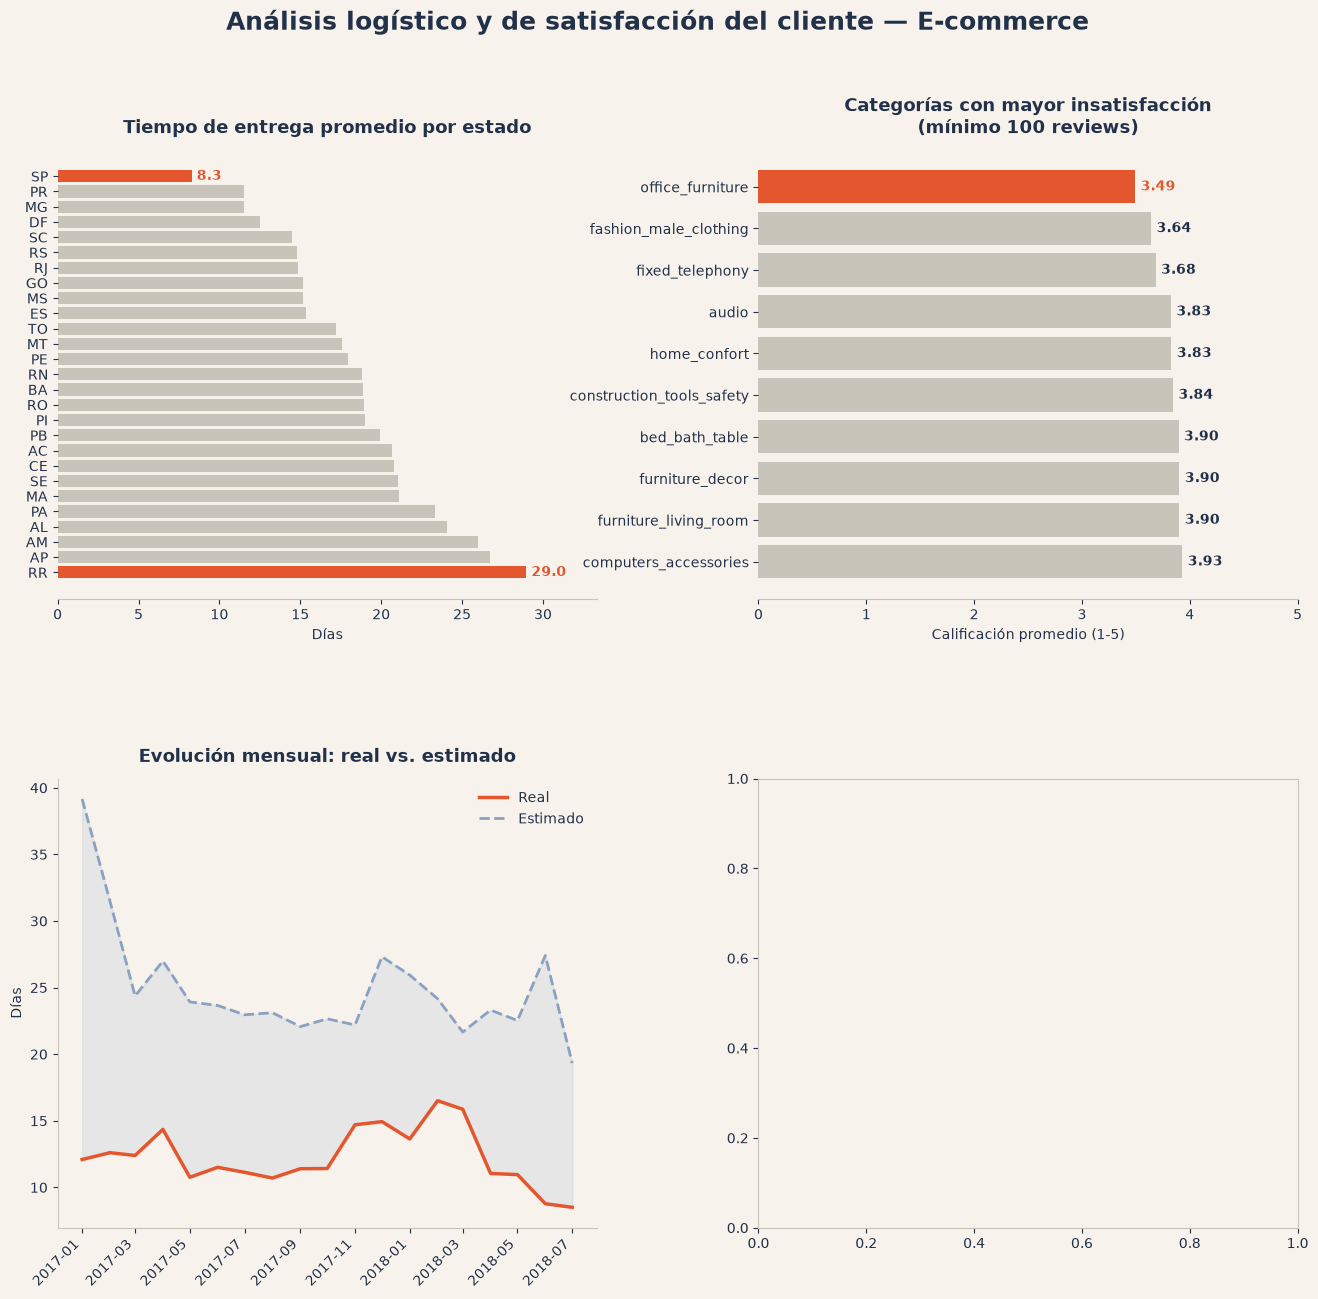

In [80]:
fig

In [82]:
ax4.axis('off')

kpis = [
    ('23.4', 'días promedio\nprometidos', TEXT),
    ('12.1', 'días promedio\nreales', ACCENT),
    ('+11.3', 'días de anticipación\npromedio', ACCENT),
]

posiciones_x = [0.17, 0.5, 0.83]

for x, (numero, etiqueta, color) in zip(posiciones_x, kpis):
    ax4.text(x, 0.6, numero, transform=ax4.transAxes,
              fontsize=32, fontweight='bold', color=color,
              ha='center', va='center')
    ax4.text(x, 0.35, etiqueta, transform=ax4.transAxes,
              fontsize=10, color=TEXT,
              ha='center', va='center')

ax4.set_title('La promesa vs. la realidad', fontsize=13, fontweight='bold', pad=12)

fig.subplots_adjust(wspace=0.3, hspace=0.4)

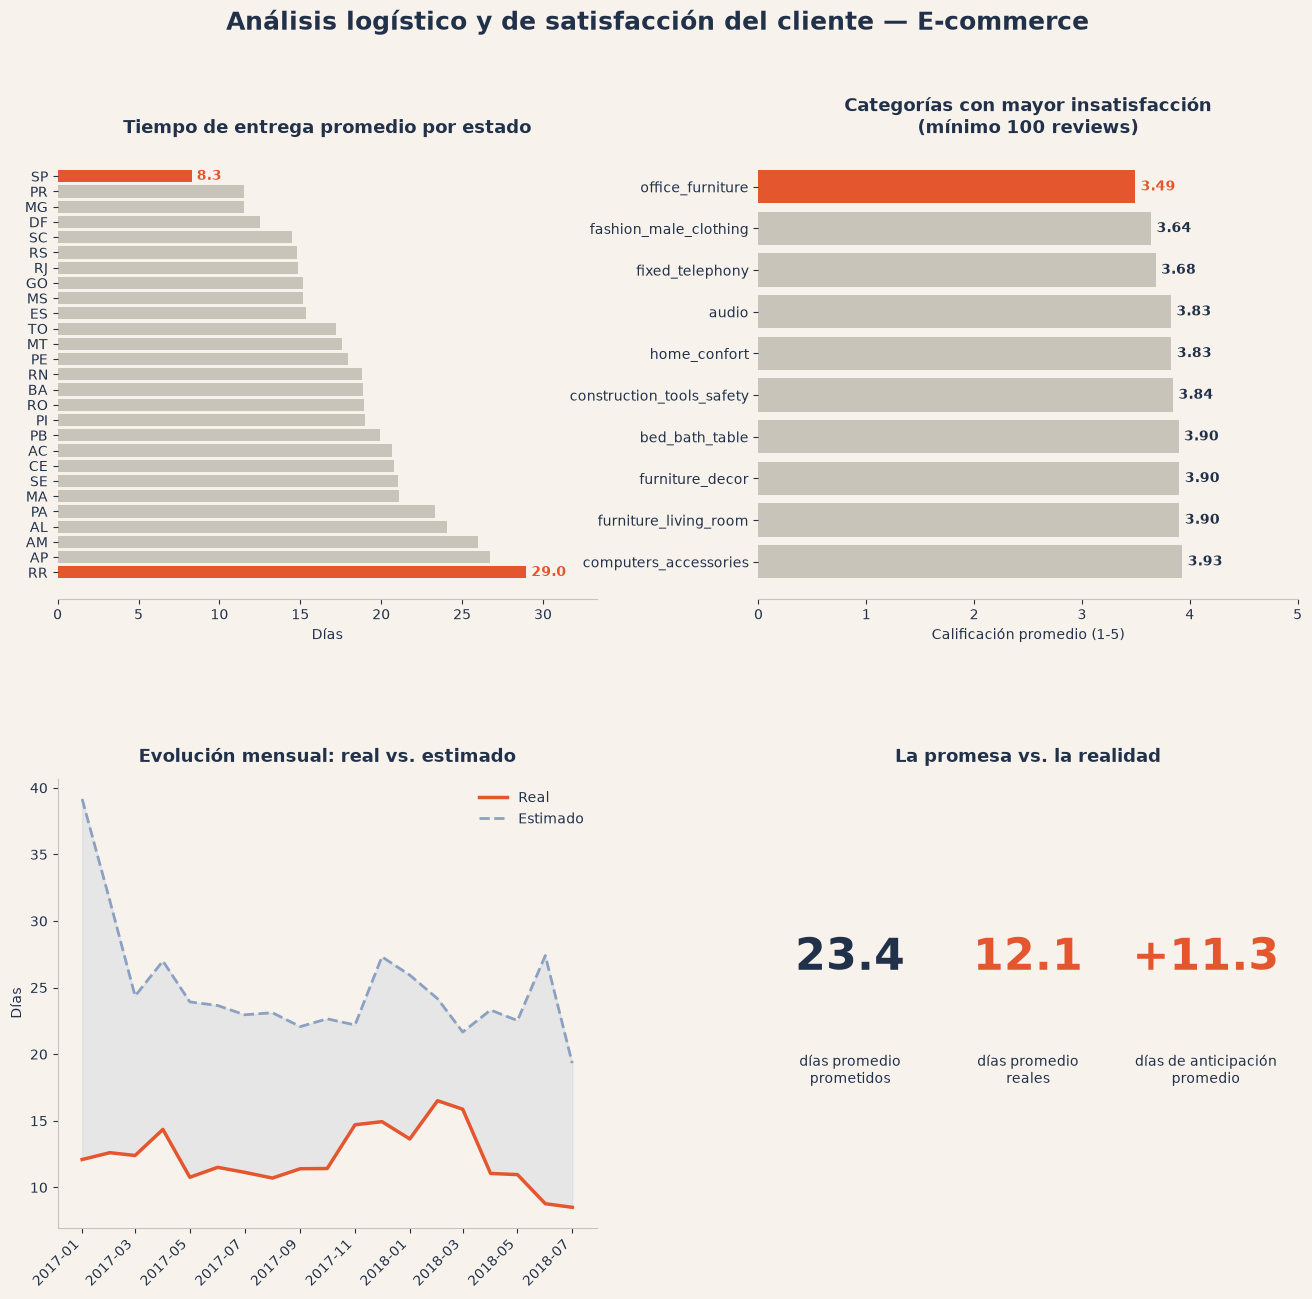

In [83]:
fig

In [84]:
fig.savefig('dashboard_ecommerce.png', dpi=300, facecolor=BG, bbox_inches='tight')